In [18]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchsummary import summary
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import *

device='cuda' if torch.cuda.is_available() else "cpu"

In [19]:
df=pd.read_csv(r'riceClassification.csv')

In [20]:
df.dropna(inplace=True)

In [21]:
original_df=df.copy()
for columns in df.columns:
    df[columns]=df[columns]/df[columns].abs().max()

In [22]:
x=np.array(df.iloc[:,:-1])
y=np.array(df.iloc[:,-1])

In [23]:
min_len = min(len(x), len(y))
x = x[:min_len]
y = y[:min_len]

In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [25]:
x_test,x_val,y_test,y_val=train_test_split(x_test,y_test,test_size=0.5)

In [26]:
x_train = x[:1000]
x_val = x[1000:1200]
x_test = x[1200:]

In [27]:
class dataset(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32).to(device)
        self.y=torch.tensor(y,dtype=torch.float32).to(device)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        if index >= len(self.x):
            raise IndexError(f"Index {index} is out of bounds for dataset with length {len(self.x)}")
        return self.x[index], self.y[index]
training_data=dataset(x_train,y_train)
validation_data=dataset(x_val,y_val)
testing_data=dataset(x,y_train)
        


In [28]:
train_dataloader=DataLoader(training_data,batch_size=8,shuffle=True)
validation_data=DataLoader(validation_data,batch_size=8,shuffle=True)
testing_dataloader=DataLoader(testing_data,batch_size=8,shuffle=True,drop_last=True)

In [29]:
from torch.utils.data import random_split

dataset = dataset(x, y)
train_len = int(0.7 * len(dataset))
val_len = int(0.2 * len(dataset))
test_len = len(dataset) - train_len - val_len

train_data, val_data, test_data = random_split(dataset, [train_len, val_len, test_len])

In [30]:
# train_dataset = dataset(x_train, y_train)
testing_dataloader = DataLoader(train_data, batch_size=8, shuffle=True)

In [31]:
HIDDEN_NEURONS=10
INPUT_FEATURES = 20
class mymodel(nn.Module):
    def __init__(self,input_dim):
        super(mymodel,self).__init__()
        self.input_layer=nn.Linear(x.shape[1],HIDDEN_NEURONS)
        self.linear=nn.Linear(HIDDEN_NEURONS,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,x):
        x=self.input_layer(x)
        x=self.linear(x)
        x=self.sigmoid(x)
        return x
input_dim = x.shape[1]  # dynamically get input size
model = mymodel(input_dim).to(device)

In [32]:
## loss and optimization
criterion=nn.BCELoss()
optimizer=Adam(model.parameters(),lr=1e-3)

In [33]:
summary(model, input_size=(input_dim,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             120
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 131
Trainable params: 131
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [34]:
criterion=nn.BCELoss()
optimizer=Adam(model.parameters(),lr=1e-3)

In [35]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

num_epochs = 10

for epoch in range(num_epochs):
    total_acc_train = 0.0
    total_loss_train = 0.0

    model.train()
    for inputs, labels in train_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        prediction = model(inputs)

        # If using BCELoss, ensure labels are reshaped to match prediction
        labels = labels.view(-1, 1).float()
        batch_loss = criterion(prediction, labels)

        batch_loss.backward()
        optimizer.step()

        total_loss_train += batch_loss.item()

        # Accuracy calculation
        acc = ((prediction > 0.5).float() == labels).float().mean().item()
        total_acc_train += acc

    avg_loss = total_loss_train / len(train_dataloader)
    avg_acc = total_acc_train / len(train_dataloader)

    total_loss_train_plot.append(avg_loss)
    total_acc_train_plot.append(avg_acc)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {avg_acc:.4f}")


Epoch 1: Loss = 0.6966, Accuracy = 0.5040
Epoch 2: Loss = 0.6898, Accuracy = 0.5460
Epoch 3: Loss = 0.6902, Accuracy = 0.5460
Epoch 4: Loss = 0.6900, Accuracy = 0.5460
Epoch 5: Loss = 0.6898, Accuracy = 0.5450
Epoch 6: Loss = 0.6902, Accuracy = 0.5460
Epoch 7: Loss = 0.6904, Accuracy = 0.5460
Epoch 8: Loss = 0.6898, Accuracy = 0.5460
Epoch 9: Loss = 0.6905, Accuracy = 0.5460
Epoch 10: Loss = 0.6897, Accuracy = 0.5460


In [36]:
model.eval()  # Set model to evaluation mode
total_loss_test = 0.0
total_acc_test = 0.0

with torch.no_grad():
    for inputs, labels in testing_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.view(-1, 1).float()  # reshape for BCELoss

        # Forward pass
        prediction = model(inputs)

        # Compute batch loss
        batch_loss = criterion(prediction, labels)
        total_loss_test += batch_loss.item() * inputs.size(0)  # sum over batch

        # Compute batch accuracy
        batch_acc = ((prediction > 0.5).float() == labels).sum().item()
        total_acc_test += batch_acc

# Compute average metrics per sample
avg_loss = total_loss_test / len(testing_dataloader.dataset)
avg_acc = total_acc_test / len(testing_dataloader.dataset)

print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Accuracy: {avg_acc * 100:.2f}%")


Test Loss: 0.7307
Test Accuracy: 54.87%


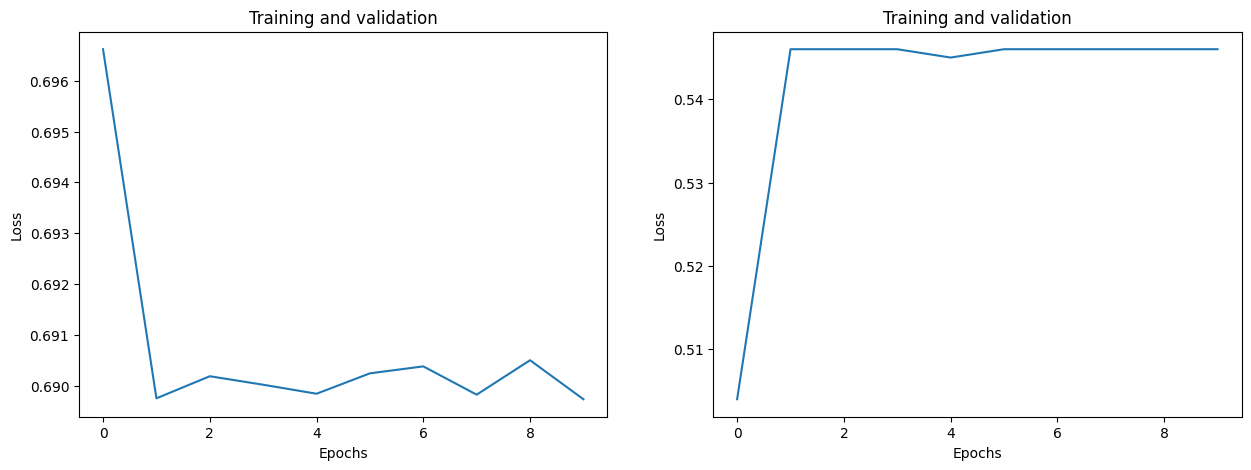

In [37]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label='Training loss')
axs[0].set_title("Training and validation")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel('Loss')
axs[1].plot(total_acc_train_plot,label='Training loss')
axs[1].set_title("Training and validation")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel('Loss')
plt.show()

In [38]:
original_df

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18180,18181,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,18182,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,18183,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,18184,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [39]:
area = 2353 / original_df['Area'].abs().max()
MajorAxislength = 81 / original_df['MajorAxisLength'].abs().max()  # <-- added ()
MinorAxislength = 42 / original_df['MinorAxisLength'].abs().max()  # <-- fixed column name and added ()


In [40]:
area=area.astype('float')
MajorAxislength=MajorAxislength.astype('float32')
MinorAxislength =MinorAxislength .astype('float32')

In [41]:
input_tensor=torch.tensor([area, MajorAxislength, MinorAxislength], dtype=torch.float32).unsqueeze(0).to(device)

In [42]:
other_features = torch.zeros(1, 8)  # fill remaining 8 features with zeros
input_tensor = torch.tensor([area, MajorAxislength, MinorAxislength], dtype=torch.float32).unsqueeze(0)
input_tensor = torch.cat([input_tensor, other_features], dim=1).to(device)

model.eval()
with torch.no_grad():
    prediction = model(input_tensor)

prediction

tensor([[0.5210]])